# Project 2: Super Bowl Ad Revenue
### Reading the CSV and Exploring 52 Years of Super Bowl Data (1967–2018)

---

**Dataset:** `ThrowbackDataThursday 2019 Week 5 - Super Bowl.csv`

**What you will learn:**
1. Load the Super Bowl CSV into a pandas DataFrame
2. Inspect it — shape, columns, types, missing values
3. Clean a messy date column and convert data types
4. Analyze how ad prices and viewership have grown over 52 years
5. Compare networks and make charts

> **Key Column:** `Cost Per 30s Ad` — how much it costs to run a 30-second commercial during the Super Bowl.


---
## Import Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt



---
## Load the CSV File

Notice the file name has spaces in it, that's fine, just put the full name in quotes.

In [2]:
df = pd.read_csv('ThrowbackDataThursday 2019 Week 5 - Super Bowl.csv')

print('File loaded!')
print(f'Shape: {df.shape[0]} rows and {df.shape[1]} columns')

File loaded!
Shape: 52 rows and 19 columns


---
## Preview the Data

In [3]:
df.head()

,index,Game,Date,Winning team,Winning Team Points,Winning Team Conference,Score,Losing team,Losing Team Points,Losing Team Conference,Venue,City,Attendance,Network,Average U.S. Viewers,Rating,Share,Cost Per 30s Ad,Notes
0,0,I,1/15/1967,Green Bay Packers,35,NFL,35–10,Kansas City Chiefs,10,AFL,Los Angeles Memorial Coliseum,"Los Angeles, California",61946,CBS/NBC,51180000,41.1,79.0,40000,"Super Bowl I was aired on both CBS and NBC, va..."
1,1,II,1/14/1968,Green Bay Packers,33,NFL,33–14,Oakland Raiders,14,AFL,Miami Orange Bowl,"Miami, Florida",75546,CBS,39120000,36.8,68.0,54500,NaN
2,2,III,1/12/1969,New York Jets,16,AFL,16–7,Baltimore Colts,7,NFL,Miami Orange Bowl,"Miami, Florida",75389,NBC,41660000,36.0,70.0,55000,NaN
3,3,IV,1/11/1970,Kansas City Chiefs,23,AFL,23–7,Minnesota Vikings,7,NFL,Tulane Stadium,"New Orleans, Louisiana",80562,CBS,44270000,39.4,69.0,78200,NaN
4,4,V,1/17/1971,Baltimore Colts,16,AFC,16–13,Dallas Cowboys,13,NFC,Miami Orange Bowl,"Miami, Florida",79204,NBC,46040000,39.9,75.0,72500,NaN


---
## Check Column Names and Types

In [4]:
print('Columns:')
print(df.columns.tolist())
print()
df.info()

Columns:
['index', 'Game', 'Date', 'Winning team', 'Winning Team Points', 'Winning Team Conference', 'Score', 'Losing team', 'Losing Team Points', 'Losing Team Conference', 'Venue', 'City', 'Attendance', 'Network', 'Average U.S. Viewers', 'Rating', 'Share', 'Cost Per 30s Ad', 'Notes']

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52 entries, 0 to 51
Data columns (total 19 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   index                    52 non-null     int64  
 1   Game                     52 non-null     object 
 2   Date                     52 non-null     object 
 3   Winning team             52 non-null     object 
 4   Winning Team Points      52 non-null     int64  
 5   Winning Team Conference  52 non-null     object 
 6   Score                    52 non-null     object 
 7   Losing team              52 non-null     object 
 8   Losing Team Points       52 non-null     int64  
 9   Losing Team

---
## Check for Missing Values

In [5]:
print('Missing values per column:')
print(df.isnull().sum())

Missing values per column:
index                       0
Game                        0
Date                        0
Winning team                0
Winning Team Points         0
Winning Team Conference     0
Score                       0
Losing team                 0
Losing Team Points          0
Losing Team Conference      0
Venue                       0
City                        0
Attendance                  0
Network                     0
Average U.S. Viewers        0
Rating                      0
Share                       0
Cost Per 30s Ad             0
Notes                      51
dtype: int64


---
## Get Statistics

In [6]:
df.describe()

,index,Winning Team Points,Losing Team Points,Attendance,Average U.S. Viewers,Rating,Share,Cost Per 30s Ad
count,52.000000,52.000000,52.000000,52.000000,5.200000e+01,52.000000,52.000000,5.200000e+01
mean,25.500000,30.423077,16.384615,77455.942308,8.226169e+07,44.451923,66.240385,1.483956e+06
std,15.154757,9.657561,7.306065,10373.651925,1.990931e+07,5.863830,7.638095,1.499618e+06
min,0.000000,14.000000,3.000000,61946.000000,3.912000e+07,36.000000,33.400000,4.000000e+04
25%,12.750000,23.750000,10.000000,71419.000000,7.451800e+07,41.375000,63.000000,2.127500e+05
50%,25.500000,30.500000,17.000000,74083.000000,8.538500e+07,43.400000,67.000000,8.500000e+05
75%,38.250000,35.000000,21.000000,80280.750000,9.272350e+07,46.325000,70.250000,2.389024e+06
max,51.000000,55.000000,33.000000,103985.000000,1.144420e+08,71.000000,79.000000,5.000000e+06


---
## Extract the Year from the Date Column

The `Date` column is stored as text like `1/15/1967`.  
We need to pull out just the year so we can plot trends over time.

In [7]:
# The date format is M/DD/YYYY — split by '/' and take the last part
df['Year'] = df['Date'].str.split('/').str[-1].astype(int)

# Some old entries store year as 2-digit — fix those
df.loc[df['Year'] < 100, 'Year'] += 1900

print('Year column added!')
print(df[['Date', 'Year']].head())

Year column added!
        Date  Year
0  1/15/1967  1967
1  1/14/1968  1968
2  1/12/1969  1969
3  1/11/1970  1970
4  1/17/1971  1971


---
## Convert Ad Cost to a Number (Clean the Data)

The `Cost Per 30s Ad` column has commas in big numbers like `5,000,000`.  
Python can't do math on those — we need to remove the commas first.

In [8]:
# Remove commas and convert to integer
df['Ad_Cost'] = df['Cost Per 30s Ad'].astype(str).str.replace(',', '').astype(int)

# Also convert viewers to millions (easier to read)
df['Viewers_M'] = df['Average U.S. Viewers'].astype(str).str.replace(',', '').astype(int) / 1_000_000

# Convert cost to thousands too (easier to read on charts)
df['Ad_Cost_K'] = df['Ad_Cost'] / 1000

print('Data cleaned!')
df[['Game', 'Year', 'Ad_Cost', 'Ad_Cost_K', 'Viewers_M']].head()

Data cleaned!


,Game,Year,Ad_Cost,Ad_Cost_K,Viewers_M
0,I,1967,40000,40.0,51.18
1,II,1968,54500,54.5,39.12
2,III,1969,55000,55.0,41.66
3,IV,1970,78200,78.2,44.27
4,V,1971,72500,72.5,46.04


---
## Basic Analysis

Now that the data is clean, let's answer some basic business questions.

In [9]:
print('=== Super Bowl Ad Revenue: Key Facts ===')
print(f"First Super Bowl (1967) ad cost:  ${df['Ad_Cost'].min():>12,.0f}")
print(f"Last Super Bowl  (2018) ad cost:  ${df['Ad_Cost'].max():>12,.0f}")
print(f"Average ad cost across all games: ${df['Ad_Cost'].mean():>12,.0f}")
print(f"Peak U.S. viewership:              {df['Viewers_M'].max():.1f} million")
print(f"Average U.S. viewership:           {df['Viewers_M'].mean():.1f} million")
print(f"Total Super Bowls in dataset:      {len(df)}")

=== Super Bowl Ad Revenue: Key Facts ===
First Super Bowl (1967) ad cost:  $      40,000
Last Super Bowl  (2018) ad cost:  $   5,000,000
Average ad cost across all games: $   1,483,956
Peak U.S. viewership:              114.4 million
Average U.S. viewership:           82.3 million
Total Super Bowls in dataset:      52


---
## See Unique Networks

Which TV networks have broadcast the Super Bowl?

In [10]:
print('Networks that aired the Super Bowl:')
print(df['Network'].value_counts())

Networks that aired the Super Bowl:
Network
CBS        18
NBC        18
Fox         8
ABC         7
CBS/NBC     1
Name: count, dtype: int64


---
## Sort: Most Expensive Super Bowl Ads

In [11]:
most_expensive = df.sort_values('Ad_Cost', ascending=False).head(10)
most_expensive[['Game', 'Year', 'Winning team', 'Network', 'Ad_Cost_K', 'Viewers_M']]

,Game,Year,Winning team,Network,Ad_Cost_K,Viewers_M
50,LI,2017,New England Patriots,Fox,5000.0,111.319
51,LII,2018,Philadelphia Eagles,NBC,5000.0,103.390
49,50,2016,Denver Broncos,CBS,5000.0,111.864
48,XLIX,2015,New England Patriots,NBC,4500.0,114.442
47,XLVIII,2014,Seattle Seahawks,Fox,4000.0,112.191
46,XLVII,2013,Baltimore Ravens,CBS,4000.0,108.693
45,XLVI,2012,New York Giants,NBC,3500.0,111.346
44,XLV,2011,Green Bay Packers,Fox,3100.0,111.041
42,XLIII,2009,Pittsburgh Steelers,NBC,3000.0,98.732
43,XLIV,2010,New Orleans Saints,CBS,2800.0,106.476


---
## Group: Average Ad Cost by Network

In [12]:
# Filter out the CBS/NBC shared broadcast (only 1 game, not a fair comparison)
df_nets = df[df['Network'] != 'CBS/NBC']

avg_by_network = df_nets.groupby('Network')['Ad_Cost_K'].mean().sort_values(ascending=False)

print('Average 30-second ad cost ($K) by network:')
print(avg_by_network.round(1))

Average 30-second ad cost ($K) by network:
Network
Fox    2775.0
ABC    1417.1
NBC    1258.8
CBS    1241.5
Name: Ad_Cost_K, dtype: float64


---
## Chart: Ad Cost Over Time

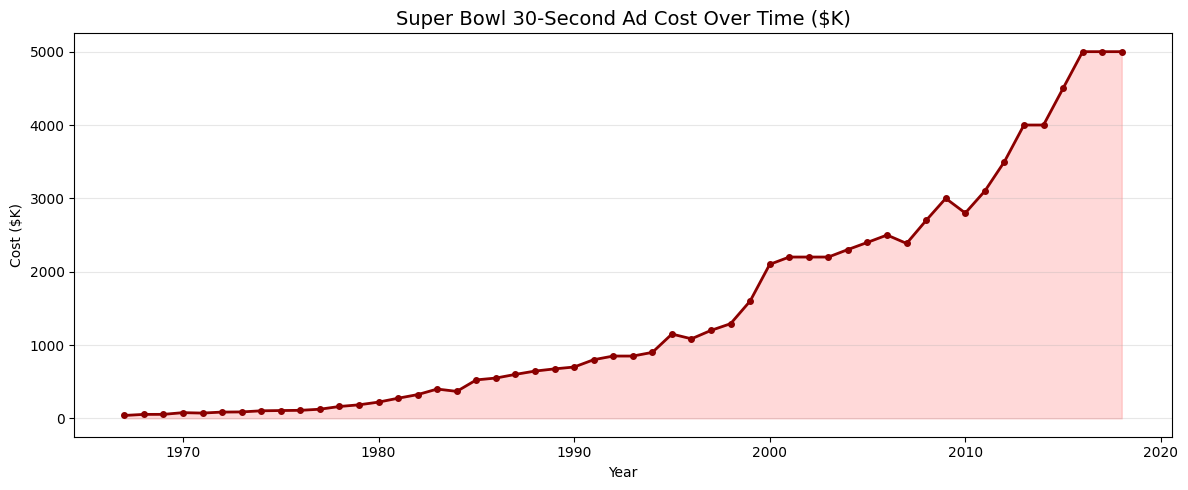

In [13]:
plt.figure(figsize=(12, 5))
plt.plot(df['Year'], df['Ad_Cost_K'], color='darkred', linewidth=2, marker='o', markersize=4)
plt.fill_between(df['Year'], df['Ad_Cost_K'], alpha=0.15, color='red')

plt.title('Super Bowl 30-Second Ad Cost Over Time ($K)', fontsize=14)
plt.xlabel('Year')
plt.ylabel('Cost ($K)')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

---
## Chart: Viewership Over Time

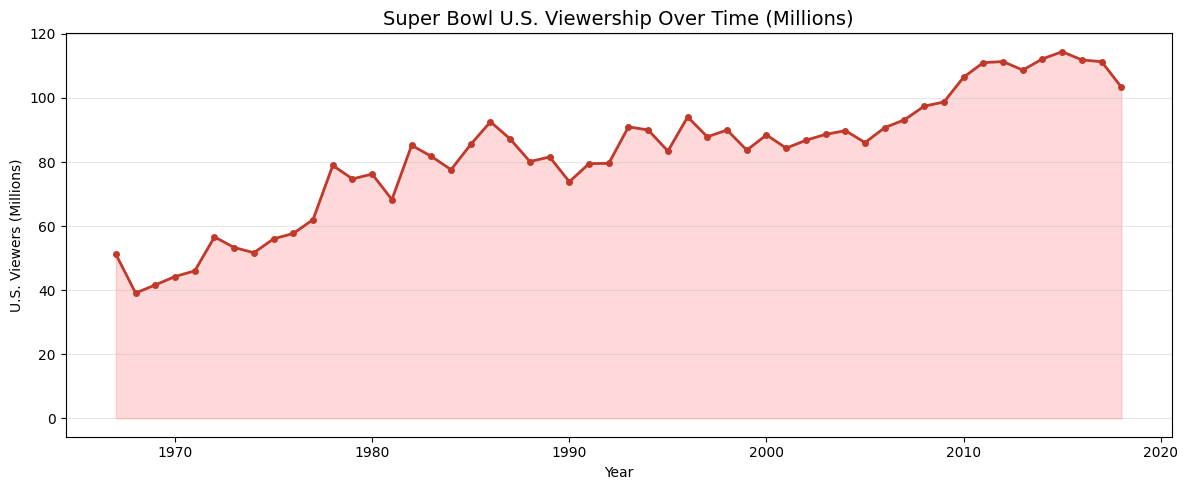

In [14]:
plt.figure(figsize=(12, 5))
plt.plot(df['Year'], df['Viewers_M'], color='#c0392b', linewidth=2, marker='o', markersize=4)
plt.fill_between(df['Year'], df['Viewers_M'], alpha=0.15, color='red')

plt.title('Super Bowl U.S. Viewership Over Time (Millions)', fontsize=14)
plt.xlabel('Year')
plt.ylabel('U.S. Viewers (Millions)')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

---
## Chart: Viewership vs. Ad Cost (Scatter Plot)

Each dot is one Super Bowl. Do games with more viewers cost more to advertise in?

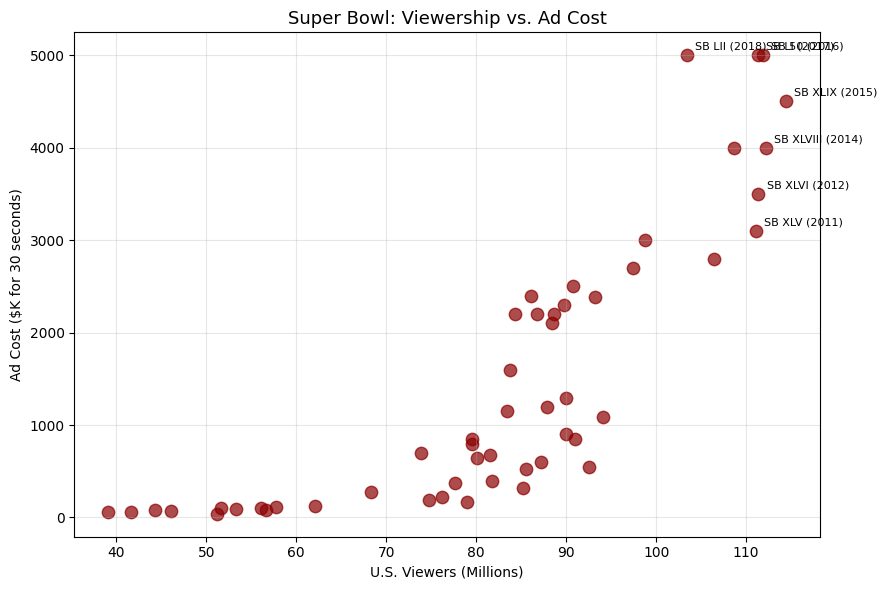

In [15]:
plt.figure(figsize=(9, 6))
plt.scatter(df['Viewers_M'], df['Ad_Cost_K'], color='darkred', alpha=0.7, s=80)

# Label a few interesting points
for _, row in df.iterrows():
    if row['Ad_Cost_K'] > 4000 or row['Viewers_M'] > 110:
        plt.annotate(f"SB {row['Game']} ({row['Year']})",
                     (row['Viewers_M'], row['Ad_Cost_K']),
                     textcoords='offset points', xytext=(6, 4), fontsize=8)

plt.title('Super Bowl: Viewership vs. Ad Cost', fontsize=13)
plt.xlabel('U.S. Viewers (Millions)')
plt.ylabel('Ad Cost ($K for 30 seconds)')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

---
## Chart: Average Ad Cost by Network

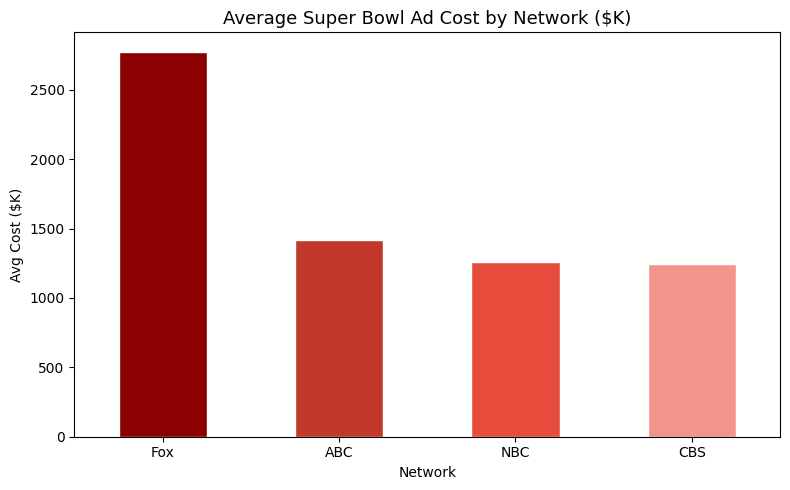

In [16]:
avg_by_network.plot(kind='bar', color=['#8b0000','#c0392b','#e74c3c','#f1948a'],
                    edgecolor='white', figsize=(8, 5))

plt.title('Average Super Bowl Ad Cost by Network ($K)', fontsize=13)
plt.xlabel('Network')
plt.ylabel('Avg Cost ($K)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

---
## What We Used

| Code | What it does |
|------|--------------|
| `pd.read_csv('file.csv')` | Load CSV |
| `df.head()` | First 5 rows |
| `df.shape` | (rows, columns) |
| `df.info()` | Summary + types |
| `df.describe()` | Min/max/avg stats |
| `df.isnull().sum()` | Missing values |
| `df['col'].str.split('/').str[-1]` | Extract part of text |
| `df['col'].str.replace(',','')` | Remove characters |
| `.astype(int)` | Convert to number |
| `df['col'].value_counts()` | Count each value |
| `df.sort_values('col', ascending=False)` | Sort biggest first |
| `df.groupby('col').mean()` | Group + average |
| `plt.plot()` | Line chart |
| `plt.scatter()` | Scatter plot |
| `plt.bar()` | Bar chart |

---
**You've analyzed 52 years of Super Bowl data!**  
Next step: build a predictive model to forecast future ad costs.